In [2]:
import pandas as pd

df = pd.read_csv("global_energy_mix.csv")

print(df.columns)

Index(['Country', 'Region', 'Source', 'Share_pct', 'TWh'], dtype='object')


Index(['Country', 'Region', 'Source', 'Share_pct', 'TWh'], dtype='object')


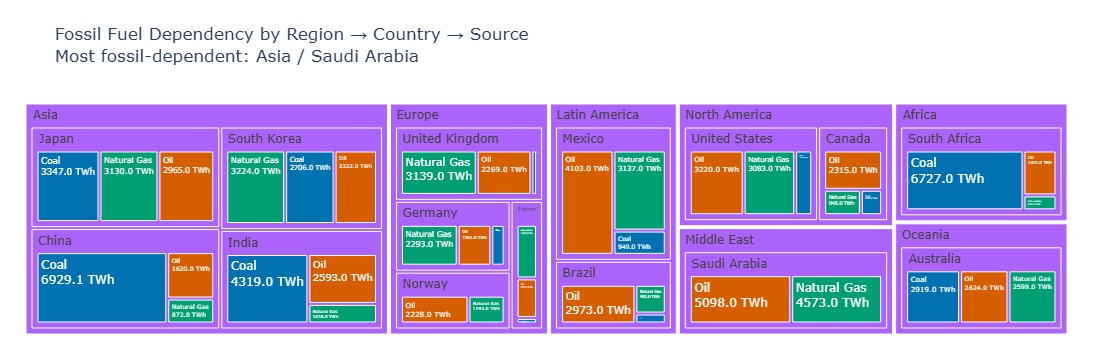

In [3]:
# Task 1 - Treemap: fossil fuel dependency by country

import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("global_energy_mix.csv")

# Check columns if needed
print(df.columns)

# Filter fossil sources only
df_fossil = df.loc[
    df['Source'].isin(['Coal', 'Oil', 'Natural Gas'])
].copy()

# Find most fossil-dependent region and country
top_region = (
    df_fossil.groupby("Region")["TWh"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

top_country = (
    df_fossil.groupby("Country")["TWh"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

# Create treemap
fig = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        "Coal": "#0072B2",
        "Oil": "#D55E00",
        "Natural Gas": "#009E73"
    },
    title=f"Fossil Fuel Dependency by Region → Country → Source<br>"
          f"Most fossil-dependent: {top_region} / {top_country}"
)

# Show TWh values only
fig.update_traces(
    texttemplate="%{label}<br>%{value:.1f} TWh",
    textinfo="label+value"
)

# Grey parent nodes
fig.update_layout(
    treemapcolorway=["#0072B2", "#D55E00", "#009E73"],
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.show()

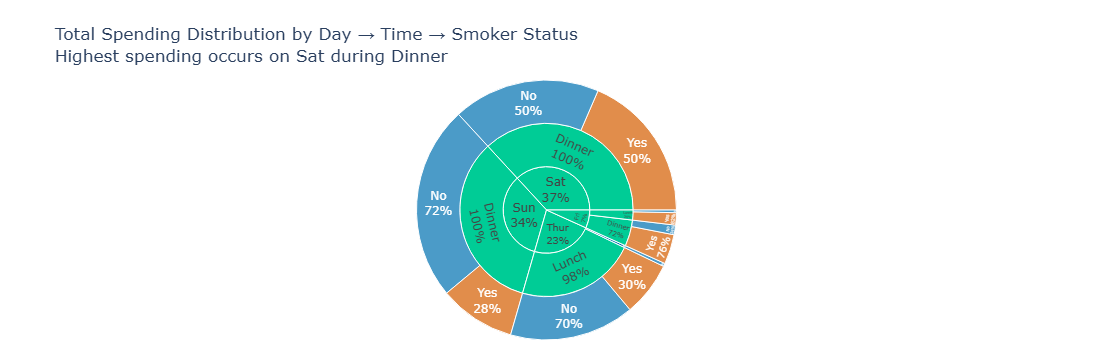

In [4]:
# Task 2 - Sunburst: tipping behaviour by day and meal time

import pandas as pd
import plotly.express as px

# Load built-in tips dataset
tips = px.data.tips()

# Aggregate total bill (sum, not count)
tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

# Find where most spending happens
top_spending = (
    tips_grouped.groupby(['day', 'time'])['total_bill']
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

top_day = top_spending[0]
top_time = top_spending[1]

# Create sunburst
fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        "Yes": "#D55E00",   # CVD-safe orange
        "No": "#0072B2"     # CVD-safe blue
    },
    title=f"Total Spending Distribution by Day → Time → Smoker Status<br>"
          f"Highest spending occurs on {top_day} during {top_time}"
)

# Show percentages of parent only
fig.update_traces(
    textinfo="label+percent parent"
)

# Grey out parent nodes
fig.update_layout(
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.show()

Index(['Country', 'Region', 'Source', 'Share_pct', 'TWh'], dtype='object')


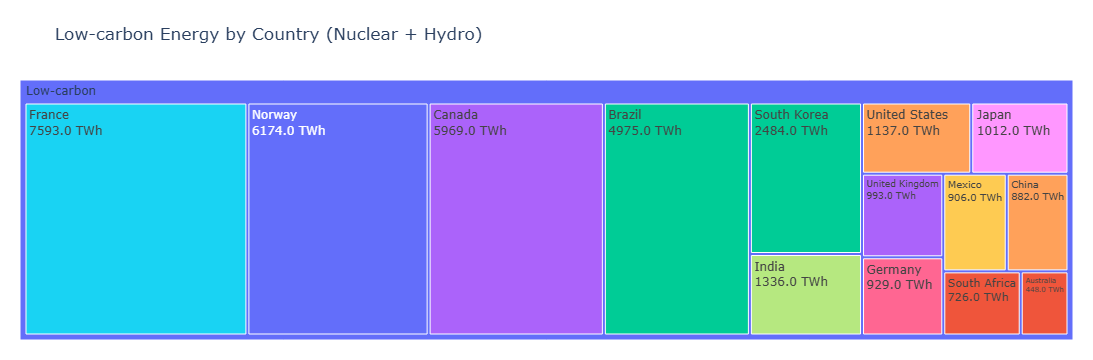

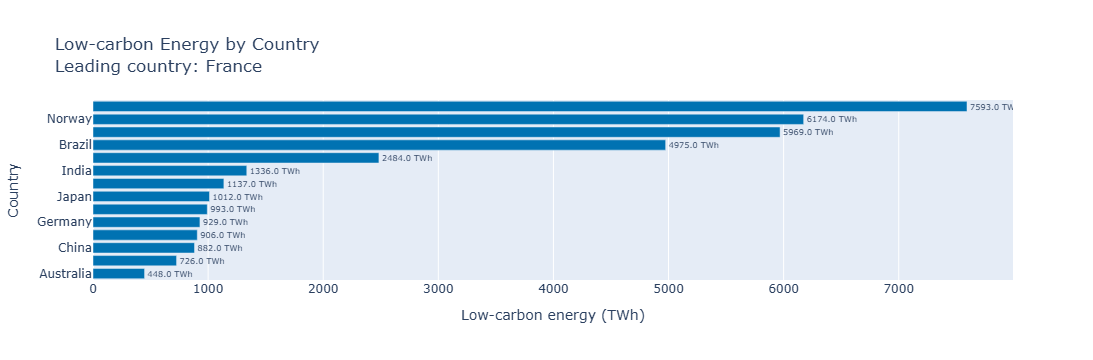

In [6]:
# Task 3 - Treemap vs bar: low-carbon energy by country

import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("global_energy_mix.csv")

# Check column names if needed
print(df.columns)

# Filter low-carbon sources (Nuclear + Hydro)
df_low = df.loc[
    df['Source'].isin(['Nuclear', 'Hydro'])
].copy()

# Aggregate TWh by country
country_low = (
    df_low.groupby('Country')['TWh']
    .sum()
    .reset_index()
)

# Add dummy root for treemap
country_low['All'] = "Low-carbon"

# Leading country
top_country = (
    country_low.sort_values('TWh', ascending=False)
    .iloc[0]['Country']
)


# -------------------------
# Treemap
# -------------------------

fig_tree = px.treemap(
    country_low,
    path=['All', 'Country'],
    values='TWh',
    color='Country',
    title="Low-carbon Energy by Country (Nuclear + Hydro)"
)

fig_tree.update_traces(
    texttemplate="%{label}<br>%{value:.1f} TWh",
    textinfo="label+value"
)

fig_tree.update_layout(
    margin=dict(t=80, l=20, r=20, b=20)
)

fig_tree.show()


# -------------------------
# Horizontal Bar Chart
# -------------------------

country_low_sorted = country_low.sort_values(
    'TWh',
    ascending=True
)

fig_bar = px.bar(
    country_low_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color_discrete_sequence=["#0072B2"],
    title=f"Low-carbon Energy by Country<br>"
          f"Leading country: {top_country}"
)

fig_bar.update_traces(
    texttemplate="%{x:.1f} TWh",
    textposition="outside"
)

fig_bar.update_layout(
    xaxis_title="Low-carbon energy (TWh)",
    yaxis_title="Country"
)

fig_bar.show()